# Google Search Analytics Intelligence System

Cross-platform SEO and engagement analysis integrating Google Search Console and Google Analytics 4 to evaluate content performance across visibility, traffic, and engagement dimensions.

## Business Problem

SEO reporting tools often measure visibility and engagement separately. This project investigates whether pages that rank well in search engines also satisfy user intent once users land on the website.

The analysis integrates Google Search Console and Google Analytics 4 datasets to evaluate content performance across visibility, traffic, and engagement dimensions.

In [1]:
import pandas as pd

## Data Loading

Raw exports from Google Search Console are loaded into Pandas DataFrames for preprocessing and analysis.

To preserve client privacy while still documenting the pipeline, displayed URLs are anonymized in notebook previews.

In [2]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir('.'))
print("Parent directory contents:", os.listdir('..'))

Current working directory: c:\Users\LENOVO\Desktop\SEO Analysis\google-analysis\notebook-google
Files here: ['google-seo-analysis.ipynb']
Parent directory contents: ['notebook-google', 'output-google', 'README.md']


In [3]:
gsc_pages = pd.read_csv('../../data/gsc_pages.csv')
gsc_queries = pd.read_csv('../../data/gsc_queries.csv')

print(gsc_pages.head().assign(**{
    'Top pages': gsc_pages['Top pages'].head().str.replace(
        r'https?://[^/]+',
        '[client-site]',
        regex=True
    )
}))

print(f"gsc_queries loaded: {gsc_queries.shape[0]} rows, {gsc_queries.shape[1]} columns")

                                           Top pages  Clicks  Impressions  \
0                                     [client-site]/     585         4435   
1               [client-site]/blogs/paypal-in-nepal/     349        61503   
2                                [client-site]/zoom/     107         4076   
3  [client-site]/blogs/zoom-not-working-troublesh...     102        26600   
4  [client-site]/blogs/aws-in-2026-latest-service...      29        80547   

      CTR  Position  
0  13.19%      5.27  
1   0.57%      4.46  
2   2.63%     11.57  
3   0.38%      6.22  
4   0.04%      6.44  
gsc_queries loaded: 1000 rows, 5 columns


## GA4 Cleaning

GA4 exports contain metadata rows before the actual dataset header. These rows are removed before analysis.

In [4]:
file_path = '../../data/ga4_landing_page.csv'

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

header_index = None
for i, line in enumerate(lines):
    if line.startswith("Landing page"):
        header_index = i
        break

print("GA4 header found at line:", header_index)

ga4 = pd.read_csv(file_path, skiprows=header_index)

print(ga4.head())

GA4 header found at line: 9
                                  Landing page  Sessions  Active users  \
0   /blogs/aws-in-2026-latest-services-updates       592           525   
1                                            /       572           470   
2  /blogs/simple-comparison-of-zoom-vs-discord       338           337   
3                       /blogs/paypal-in-nepal       257           215   
4  /blogs/amazon-bedrock-aws-ai-platform-guide       232           222   

   New users  Average engagement time per session  Key events  Total revenue  \
0        524                            17.701014           0              0   
1        465                            37.127622           0              0   
2        337                            14.482249           0              0   
3        215                            29.626459           0              0   
4        222                             7.564655           0              0   

   Session key event rate  
0                 

## Schema Standardization

Google Search Console and Google Analytics exports use inconsistent column naming conventions and formatting. 

This step standardizes column names, removes whitespace artifacts, and aligns key identifiers across datasets before integration.

The primary normalization task is aligning the page identifier column (`Page`) across both datasets.

In [5]:
gsc_pages.columns = gsc_pages.columns.str.strip()
gsc_queries.columns = gsc_queries.columns.str.strip()
ga4.columns = ga4.columns.str.strip()

gsc_pages = gsc_pages.rename(columns={'Top pages': 'Page'})
ga4 = ga4.rename(columns={'Landing page': 'Page'})

print("GSC columns:", gsc_pages.columns.tolist())
print("GA4 columns:", ga4.columns.tolist())

GSC columns: ['Page', 'Clicks', 'Impressions', 'CTR', 'Position']
GA4 columns: ['Page', 'Sessions', 'Active users', 'New users', 'Average engagement time per session', 'Key events', 'Total revenue', 'Session key event rate']


## URL Normalization

Google Search Console exports full canonical URLs, while Google Analytics 4 exports relative page paths. 

To ensure reliable dataset integration, URLs are normalized through the following transformations:

- remove domain names from canonical URLs,
- standardize casing,
- remove whitespace artifacts,
- remove trailing slashes,
- and filter invalid GA4 values such as `(not set)` entries.

This creates a unified `Page` identifier used for downstream merging and analysis.

In [6]:
def clean_url(col):
    return (
        col.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'https?://[^/]+', '', regex=True)
        .str.rstrip('/')
    )

gsc_pages['Page'] = clean_url(gsc_pages['Page'])
ga4['Page'] = clean_url(ga4['Page'])

ga4 = ga4[ga4['Page'].str.startswith('/')]

print("GSC sample:", gsc_pages['Page'].head(3).tolist())
print("GA4 sample:", ga4['Page'].head(3).tolist())

GSC sample: ['', '/blogs/paypal-in-nepal', '/zoom']
GA4 sample: ['/blogs/aws-in-2026-latest-services-updates', '/blogs/simple-comparison-of-zoom-vs-discord', '/blogs/paypal-in-nepal']


## Cross-platform Dataset Integration

After normalization, the Google Search Console and Google Analytics 4 datasets are merged using the unified `Page` identifier.

An inner join is used to retain only pages that exist in both systems. This ensures that every row in the final analytical dataset contains:

- search visibility metrics from GSC,
- behavioral engagement metrics from GA4,
- and a shared URL structure suitable for feature engineering.

The resulting merged table forms the core analytical layer for all downstream KPI generation, classification, and visualization tasks.

In [7]:
page_metrics = pd.merge(
    gsc_pages,
    ga4,
    on='Page',
    how='inner'
)

print(
    f"Merged dataset: "
    f"{page_metrics.shape[0]} rows, "
    f"{page_metrics.shape[1]} columns"
)

print(
    page_metrics.head().assign(
        Page=lambda df: df['Page'].str.replace(
            r'^',
            '[client-site]',
            regex=True
        )
    )
)

print("\nColumns in merged dataset:")
print(page_metrics.columns.tolist())

Merged dataset: 74 rows, 12 columns
                                                Page  Clicks  Impressions  \
0                [client-site]/blogs/paypal-in-nepal     349        61503   
1                                 [client-site]/zoom     107         4076   
2  [client-site]/blogs/zoom-not-working-troublesh...     102        26600   
3  [client-site]/blogs/aws-in-2026-latest-service...      29        80547   
4            [client-site]/cloud-consulting-in-nepal      26         1431   

     CTR  Position  Sessions  Active users  New users  \
0  0.57%      4.46       257           215        215   
1  2.63%     11.57        65            62         59   
2  0.38%      6.22       140           134        133   
3  0.04%      6.44       592           525        524   
4  1.82%     11.50        53            25         22   

   Average engagement time per session  Key events  Total revenue  \
0                            29.626459           0              0   
1                   

In [8]:
page_metrics['Page'] = page_metrics['Page'].str.replace(
    r'[a-z]+-solutions',
    '[client]',
    regex=True
)

## Schema Standardization and Type Conversion

To improve readability and downstream feature engineering, verbose platform-specific column names are standardized into a consistent analytical schema.

Additional preprocessing steps include:

- converting CTR values from percentage strings to numeric decimal format,
- ensuring numerical metrics use appropriate data types,
- and simplifying metric naming conventions across platforms.

This creates a cleaner feature space for KPI engineering and visualization.

In [9]:
page_metrics = page_metrics.rename(columns={
    'Clicks': 'gsc_clicks',
    'Impressions': 'gsc_impressions',
    'CTR': 'gsc_ctr',
    'Position': 'gsc_position',
    'Sessions': 'ga_sessions',
    'Active users': 'ga_active_users',
    'New users': 'ga_new_users',
    'Average engagement time per session': 'ga_engagement_time',
    'Key events': 'ga_conversions'
})

# Convert CTR from percentage string to decimal
page_metrics['gsc_ctr'] = (
    page_metrics['gsc_ctr']
    .str.replace('%', '', regex=False)
    .astype(float) / 100
)

print("Column data types:\n")
print(page_metrics.dtypes)

print("\nPreview of standardized dataset:\n")

print(
    page_metrics.head().assign(
        Page=lambda df: df['Page'].str.replace(
            r'^',
            '[client-site]',
            regex=True
        )
    )
)

Column data types:

Page                          str
gsc_clicks                  int64
gsc_impressions             int64
gsc_ctr                   float64
gsc_position              float64
ga_sessions                 int64
ga_active_users             int64
ga_new_users                int64
ga_engagement_time        float64
ga_conversions              int64
Total revenue               int64
Session key event rate      int64
dtype: object

Preview of standardized dataset:

                                                Page  gsc_clicks  \
0                [client-site]/blogs/paypal-in-nepal         349   
1                                 [client-site]/zoom         107   
2  [client-site]/blogs/zoom-not-working-troublesh...         102   
3  [client-site]/blogs/aws-in-2026-latest-service...          29   
4            [client-site]/cloud-consulting-in-nepal          26   

   gsc_impressions  gsc_ctr  gsc_position  ga_sessions  ga_active_users  \
0            61503   0.0057          4.

## Feature Engineering and KPI Construction

Raw platform metrics alone provide limited analytical value. To evaluate content performance more meaningfully, several derived KPIs are engineered from the merged dataset. These metrics attempt to capture relationships between visibility, acquisition behavior, and engagement quality.

### Engineered metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| `visibility_score` | impressions × CTR | Effective visibility weighted by click likelihood |
| `click_to_session_ratio` | sessions / clicks | Measures whether traffic originates primarily from organic search or other channels |
| `engagement_per_session` | avg. engagement time | Absolute engagement depth |
| `engagement_efficiency` | engagement time / sessions | Engagement intensity normalized by traffic volume |

These engineered KPIs form the basis for downstream classification, comparative analysis, and opportunity detection.

In [10]:
# Visibility weighted by click-through probability
page_metrics['visibility_score'] = (
    page_metrics['gsc_impressions'] *
    page_metrics['gsc_ctr']
)

# Relationship between organic clicks and actual sessions
page_metrics['click_to_session_ratio'] = (
    page_metrics['ga_sessions'] /
    page_metrics['gsc_clicks']
)

# Absolute engagement depth
page_metrics['engagement_per_session'] = (
    page_metrics['ga_engagement_time']
)

# Engagement intensity normalized by traffic volume
page_metrics['engagement_efficiency'] = (
    page_metrics['ga_engagement_time'] /
    page_metrics['ga_sessions']
)

print(
    page_metrics[
        [
            'Page',
            'visibility_score',
            'click_to_session_ratio',
            'engagement_efficiency'
        ]
    ].head().assign(
        Page=lambda df: df['Page'].str.replace(
            r'^',
            '[client-site]',
            regex=True
        )
    )
)

                                                Page  visibility_score  \
0                [client-site]/blogs/paypal-in-nepal          350.5671   
1                                 [client-site]/zoom          107.1988   
2  [client-site]/blogs/zoom-not-working-troublesh...          101.0800   
3  [client-site]/blogs/aws-in-2026-latest-service...           32.2188   
4            [client-site]/cloud-consulting-in-nepal           26.0442   

   click_to_session_ratio  engagement_efficiency  
0                0.736390               0.115278  
1                0.607477               1.138935  
2                1.372549               0.262857  
3               20.413793               0.029900  
4                2.038462               0.224635  


## Traffic Distribution Analysis

To understand which pages contribute most to overall acquisition, pages are ranked by GA4 session volume. This step helps identify:

- high-traffic acquisition pages,
- content clusters driving user engagement,
- and potential mismatch between search visibility (GSC) and actual traffic behavior (GA4).

The comparison between sessions, clicks, and engagement time highlights whether visibility is effectively converting into meaningful user activity.

In [11]:
page_metrics.sort_values('ga_sessions', ascending=False)[
    ['Page', 'gsc_clicks', 'gsc_impressions', 'ga_sessions', 'ga_engagement_time']
].head(10)

,Page,gsc_clicks,gsc_impressions,ga_sessions,ga_engagement_time
3,/blogs/aws-in-2026-latest-services-updates,29,80547,592,17.701014
27,/blogs/simple-comparison-of-zoom-vs-discord,2,3203,338,14.482249
0,/blogs/paypal-in-nepal,349,61503,257,29.626459
14,/blogs/amazon-bedrock-aws-ai-platform-guide,9,49523,232,7.564655
2,/blogs/zoom-not-working-troubleshoot-guide,102,26600,140,36.800000
45,/cybersecurity,0,145,87,4.954023
13,/blogs/complete-guide-to-aws-database,10,10061,78,6.948718
15,/blogs/what-is-aws-guide-amazon-web-services,8,19555,74,28.337838
1,/zoom,107,4076,65,74.030769
4,/cloud-consulting-in-nepal,26,1431,53,11.905660


## Content Performance Classification

To move beyond raw metrics, pages are categorized using a rule-based heuristic that combines visibility and engagement signals.

The classification logic segments pages into four performance archetypes:

- **High visibility / low engagement**: Pages that rank well in search but fail to retain users or match intent effectively.
- **High quality content**: Pages with strong engagement time, indicating good intent satisfaction and content depth.
- **High traffic driver**: Pages that generate significant organic clicks, representing proven demand.
- **Normal**: Baseline pages without strong signals in either direction.

This segmentation helps translate numerical KPIs into actionable content strategy insights.

In [12]:
def classify(row):
    if row['gsc_impressions'] > 20000 and row['ga_sessions'] < 100:
        return "High visibility / low engagement"
    elif row['ga_engagement_time'] > 30:
        return "High quality content"
    elif row['gsc_clicks'] > 100:
        return "High traffic driver"
    else:
        return "Normal"

page_metrics['category'] = page_metrics.apply(classify, axis=1)

page_metrics[['Page', 'category']]

,Page,category
0,/blogs/paypal-in-nepal,High traffic driver
1,/zoom,High quality content
2,/blogs/zoom-not-working-troubleshoot-guide,High quality content
3,/blogs/aws-in-2026-latest-services-updates,Normal
4,/cloud-consulting-in-nepal,Normal
...,...,...
69,/plans/zoom-webinar-plan,Normal
70,/faq/what-cloud-services-do-you-offer,Normal
71,/cloud-service,Normal
72,/faq/how-secure-is-your-cloud-infrastructure,Normal


## Query-Level Dataset Overview

Alongside page-level analysis, the Google Search Console query dataset is used to understand search demand and user intent at the keyword level. This dataset contains:

- search queries driving impressions and clicks,
- associated CTR and average ranking position,
- and a large-scale view of demand distribution across 1,000+ search terms.

Query-level analysis complements page-level metrics by explaining *why* certain pages receive traffic and what user intent they are capturing.

In [13]:
print(gsc_queries.columns.tolist())
print(gsc_queries.shape)

['Top queries', 'Clicks', 'Impressions', 'CTR', 'Position']
(1000, 5)


## Query-Level Subdataset Expansion

To deepen intent-level analysis, individual GSC query exports are loaded for key content clusters.

Each file represents a topical grouping of search queries tied to a specific content page or theme (e.g., AWS, Zoom, PayPal in Nepal).

These segmented query datasets form the basis for later intent classification and cross-page performance comparison.

In [14]:
import os

query_files = {
    'aws_bedrock': '../../data/aws_bedrock_queries.csv',
    'aws_updates': '../../data/aws_updates_queries.csv',
    'paypal_nepal': '../../data/paypal_in_nepal_queries.csv',
    'zoom': '../../data/zoom_queries.csv',
    'zoom_troubleshoot': '../../data/zoom_troubleshoot_queries.csv',
    'zoom_discord': '../../data/zoom_discord_queries.csv',
}

query_dfs = {}
for name, path in query_files.items():
    df = pd.read_csv(path)
    query_dfs[name] = df
    print(f"{name}: {df.shape[0]} rows")

aws_bedrock: 480 rows
aws_updates: 1000 rows
paypal_nepal: 510 rows
zoom: 52 rows
zoom_troubleshoot: 518 rows
zoom_discord: 51 rows


## Query Sample Inspection (Cluster-Level Validation)

Before performing intent classification or aggregation, each query subset is inspected to validate data quality and ensure consistent schema across all topic clusters. This step confirms:

- consistent column structure across all query datasets,
- presence of meaningful search terms (Top queries),
- and variation in performance signals such as clicks, impressions, and position.

This validation is critical before aggregating or comparing clusters, as inconsistencies at the query level can distort downstream intent and performance analysis.

In [15]:
for name, df in query_dfs.items():
    print(f"\n{name}:")
    print(df.head(3))


aws_bedrock:
                   Top queries  Clicks  Impressions    CTR  Position
0  amazon bedrock 2026 updates       1           13  7.69%      5.77
1                  aws bedrock       1           11  9.09%     17.36
2               how many total       1            1   100%      6.00

aws_updates:
                               Top queries  Clicks  Impressions    CTR  \
0                    aws new features 2026       1           58  1.72%   
1  how many aws services are there in 2026       1           31  3.23%   
2                          aws trends 2026       1           15  6.67%   

   Position  
0      6.69  
1      3.81  
2      6.00  

paypal_nepal:
                    Top queries  Clicks  Impressions    CTR  Position
0               paypal in nepal      44         5772  0.76%      5.70
1  is paypal available in nepal      17         3111  0.55%      4.40
2     does paypal work in nepal      12         1835  0.65%      4.27

zoom:
                  Top queries  Clicks  Im

## Query Dataset Standardization and Consolidation

Each topic-specific query dataset is standardized into a unified schema to enable cross-cluster analysis. The cleaning process includes:

- normalizing column names for consistency,
- converting CTR values from percentage strings to numeric format,
- attaching a `page` identifier to link queries back to their corresponding landing pages,
- and standardizing all datasets into a single analytical structure.

All cleaned query datasets are then concatenated into a single unified dataframe containing 2,000+ queries across all content clusters. This consolidated dataset enables:
- cross-page intent comparison,
- aggregate keyword performance analysis,
- and unified query-level feature engineering.

In [16]:
def clean_query_df(df, page_label):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'Top queries': 'query'})
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    df['ctr'] = df['ctr'].str.replace('%', '').astype(float) / 100
    df['page'] = page_label
    return df

query_dfs_clean = {
    'aws_bedrock': clean_query_df(query_dfs['aws_bedrock'], '/blogs/amazon-bedrock-aws-ai-platform-guide'),
    'aws_updates': clean_query_df(query_dfs['aws_updates'], '/blogs/aws-in-2026-latest-services-updates'),
    'paypal_nepal': clean_query_df(query_dfs['paypal_nepal'], '/blogs/paypal-in-nepal'),
    'zoom': clean_query_df(query_dfs['zoom'], '/zoom'),
    'zoom_troubleshoot': clean_query_df(query_dfs['zoom_troubleshoot'], '/blogs/zoom-not-working-troubleshoot-guide'),
    'zoom_discord': clean_query_df(query_dfs['zoom_discord'], '/blogs/simple-comparison-of-zoom-vs-discord'),
}

all_queries = pd.concat(query_dfs_clean.values(), ignore_index=True)

print(all_queries.shape)
print(all_queries.head())

(2611, 6)
                            query  clicks  impressions     ctr  position  \
0     amazon bedrock 2026 updates       1           13  0.0769      5.77   
1                     aws bedrock       1           11  0.0909     17.36   
2                  how many total       1            1  1.0000      6.00   
3        aws bedrock updates 2026       0         1643  0.0000      5.66   
4  aws bedrock updates april 2026       0          672  0.0000      7.36   

                                          page  
0  /blogs/amazon-bedrock-aws-ai-platform-guide  
1  /blogs/amazon-bedrock-aws-ai-platform-guide  
2  /blogs/amazon-bedrock-aws-ai-platform-guide  
3  /blogs/amazon-bedrock-aws-ai-platform-guide  
4  /blogs/amazon-bedrock-aws-ai-platform-guide  


## Query Intent Classification

To interpret search behavior beyond raw keywords, each query is classified into an intent category using rule-based keyword matching. The intent taxonomy includes:

- **Informational**: users seeking knowledge, definitions, guides, or explanations  
- **Commercial**: users comparing services, evaluating options, or showing purchase intent  
- **Transactional**: users attempting to take action such as buying, downloading, or subscribing  
- **Troubleshooting**: users trying to resolve technical issues or errors  
- **Local**: geographically contextual queries (e.g., “in Nepal”, “near me”)

This classification enables aggregation of search demand by intent type and helps evaluate whether content aligns with user motivation across different pages. The resulting distribution provides a high-level view of how user intent is distributed across the dataset and which content types dominate each page cluster.

In [17]:
troubleshooting = [
    'not working', 'fix', 'issue', 'problem', 'error', 'troubleshoot',
    "can't", 'cant', 'failed', 'slow', 'unable', 'connecting', "won't",
    "isn't", 'connection', 'launch'
]
transactional = [
    'buy', 'subscribe', 'get', 'order', 'sign up', 'register',
    'download', 'install', 'start'
]
commercial = [
    'price', 'cost', 'plan', 'license', 'reseller', 'provider',
    'service', 'best', 'alternative', 'subscription', 'package',
    'authorized', 'pricing', 'authorised', 'vs', 'compare',
    'comparison', 'differences', 'difference', 'better'
]
informational = [
    'what', 'how', 'why', 'when', 'where', 'who', 'is', 'are', 'does',
    'do', 'can', 'which', 'will', 'guide', 'tutorial', 'explain',
    'available', 'legal', 'work', 'use', 'come', 'news', 'meaning'
]
local = [
    'in nepal', 'near me', 'in Nepal', 'local'
]

def classify_intent(query):
    q = query.lower()
    if any(word in q for word in troubleshooting):
        return 'Troubleshooting'
    elif any(word in q for word in transactional):
        return 'Transactional'
    elif any(word in q for word in commercial):
        return 'Commercial'
    elif any(word in q for word in local):
        return 'Local'
    elif any(word in q for word in informational):
        return 'Informational'
    else:
        return 'Informational'

all_queries['intent'] = all_queries['query'].apply(classify_intent)

print(all_queries['intent'].value_counts())
print()
print(all_queries.groupby(['page', 'intent']).size().unstack(fill_value=0))

intent
Informational      1661
Commercial          506
Troubleshooting     263
Local               146
Transactional        35
Name: count, dtype: int64

intent                                       Commercial  Informational  Local  \
page                                                                            
/blogs/amazon-bedrock-aws-ai-platform-guide          87            386      0   
/blogs/aws-in-2026-latest-services-updates          346            640      0   
/blogs/paypal-in-nepal                                5            353    143   
/blogs/simple-comparison-of-zoom-vs-discord          34             16      1   
/blogs/zoom-not-working-troubleshoot-guide            9            253      0   
/zoom                                                25             13      2   

intent                                       Transactional  Troubleshooting  
page                                                                         
/blogs/amazon-bedrock-aws-ai-platform-gui

## Intent Aggregation and Page-Level Behavioral Mapping

After classifying individual queries, intent signals are aggregated at the page level to derive a dominant intent for each landing page. This is achieved by:

- grouping queries by page and intent,
- calculating aggregate performance metrics (clicks, impressions, query volume),
- and identifying the most frequent intent category per page.

The resulting `dominant_intent` represents the primary user motivation driving traffic to each page.

This dataset is then merged with page-level engagement metrics from GA4 to evaluate whether intent alignment correlates with user behavior outcomes such as engagement time and efficiency.

In [18]:
intent_summary = all_queries.groupby(['page', 'intent']).agg(
    query_count=('query', 'count'),
    total_clicks=('clicks', 'sum'),
    total_impressions=('impressions', 'sum'),
    avg_position=('position', 'mean')
).reset_index()

dominant_intent = all_queries.groupby('page')['intent'].agg(
    lambda x: x.value_counts().index[0]
).reset_index().rename(columns={'intent': 'dominant_intent'})

page_intent = page_metrics.merge(
    dominant_intent,
    left_on='Page',
    right_on='page',
    how='left'
).drop(columns='page')

print(page_intent[['Page', 'dominant_intent', 'ga_engagement_time', 'engagement_efficiency']].dropna())

                                           Page dominant_intent  \
0                        /blogs/paypal-in-nepal   Informational   
1                                         /zoom      Commercial   
2    /blogs/zoom-not-working-troubleshoot-guide   Informational   
3    /blogs/aws-in-2026-latest-services-updates   Informational   
14  /blogs/amazon-bedrock-aws-ai-platform-guide   Informational   
27  /blogs/simple-comparison-of-zoom-vs-discord      Commercial   

    ga_engagement_time  engagement_efficiency  
0            29.626459               0.115278  
1            74.030769               1.138935  
2            36.800000               0.262857  
3            17.701014               0.029900  
14            7.564655               0.032606  
27           14.482249               0.042847  


## Content Performance Quadrant Visualization

To synthesize multi-dimensional SEO performance signals, a quadrant-based visualization is constructed using:

- **X-axis:** GSC impressions (search visibility)
- **Y-axis:** engagement efficiency (GA4 engagement time normalized by sessions)
- **Bubble size:** session volume (traffic contribution)
- **Color encoding:** dominant search intent per page

This visualization enables simultaneous comparison of:

- visibility vs engagement trade-offs,
- intent-driven content performance patterns,
- and high-impact pages that combine strong reach with meaningful user behavior.

Quadrant median lines are used to segment pages into relative performance zones for strategic prioritization.

In [19]:
import os
os.makedirs('../output-google/chart/', exist_ok=True)

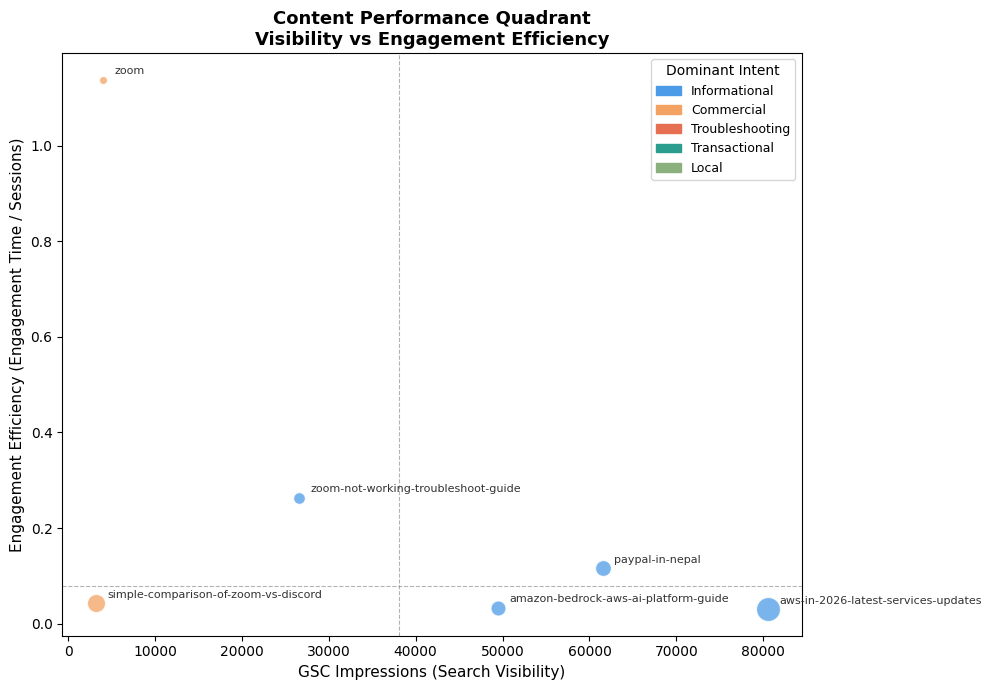

Chart saved.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))

# Use only pages with intent data
plot_data = page_intent.dropna(subset=['dominant_intent'])

colors = {
    'Informational': '#4C9BE8',
    'Commercial': '#F4A261',
    'Troubleshooting': '#E76F51',
    'Transactional': '#2A9D8F',
    'Local': '#8AB17D'
}

for _, row in plot_data.iterrows():
    color = colors.get(row['dominant_intent'], '#999999')
    ax.scatter(
        row['gsc_impressions'],
        row['engagement_efficiency'],
        color=color,
        s=row['ga_sessions'] * 0.5,
        alpha=0.75,
        edgecolors='white',
        linewidth=0.8
    )
    ax.annotate(
        row['Page'].replace('/blogs/', '').replace('/', ''),
        (row['gsc_impressions'], row['engagement_efficiency']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

# Quadrant lines
ax.axvline(x=plot_data['gsc_impressions'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=plot_data['engagement_efficiency'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Labels
ax.set_xlabel('GSC Impressions (Search Visibility)', fontsize=11)
ax.set_ylabel('Engagement Efficiency (Engagement Time / Sessions)', fontsize=11)
ax.set_title('Content Performance Quadrant\nVisibility vs Engagement Efficiency', fontsize=13, fontweight='bold')

# Legend for intent
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=legend_patches, title='Dominant Intent', loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../output-google/chart/quadrant_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

## Opportunity scoring and optimization prioritization

Traditional SEO reporting often isolates metrics such as impressions, CTR, rankings, or engagement time without identifying which pages should actually be prioritized for improvement. To address this, a composite `opportunity_score` was engineered to rank pages based on their optimization potential rather than raw performance alone.

The scoring system combines visibility, engagement quality, CTR performance, and ranking position into a unified decision-oriented metric.

### Scoring framework

| Component | Purpose |
|---|---|
| `impressions_norm` | Measures existing search visibility potential |
| `efficiency_gap` | Identifies pages with weak engagement efficiency |
| `ctr_gap` | Detects pages underperforming in search click-through |
| `position_norm` | Incorporates ranking improvement potential |

### Weighted scoring model

The final score applies the following weights:

- **35% visibility potential**
- **35% engagement weakness**
- **20% CTR weakness**
- **10% ranking position**

This weighting intentionally prioritizes pages that already attract search exposure but fail to fully satisfy user intent or convert visibility into meaningful engagement.

### Opportunity ranking visualization

The resulting scores are visualized using a horizontal ranking chart displaying the ten highest-priority pages for optimization.

Key visualization decisions include:

- horizontal bars for readability of long page labels,
- direct score annotations for quick interpretation,
- descending ranking order for prioritization clarity,
- and simplified URL labels for cleaner presentation.

Rather than functioning as a descriptive dashboard alone, this layer transforms the analysis into an actionable SEO intelligence system capable of supporting content strategy, optimization prioritization, and resource allocation decisions.

In [21]:

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

page_metrics['impressions_norm'] = normalize(page_metrics['gsc_impressions'])
page_metrics['efficiency_gap'] = 1 - normalize(page_metrics['engagement_efficiency'])
page_metrics['ctr_gap'] = 1 - normalize(page_metrics['gsc_ctr'])
page_metrics['position_norm'] = normalize(page_metrics['gsc_position'])

page_metrics['opportunity_score'] = (
    page_metrics['impressions_norm'] * 0.35 +
    page_metrics['efficiency_gap'] * 0.35 +
    page_metrics['ctr_gap'] * 0.20 +
    page_metrics['position_norm'] * 0.10
)

print(page_metrics[['Page', 'opportunity_score']].sort_values('opportunity_score', ascending=False).head(10))

                                                 Page  opportunity_score
3          /blogs/aws-in-2026-latest-services-updates           0.907404
0                              /blogs/paypal-in-nepal           0.808457
14        /blogs/amazon-bedrock-aws-ai-platform-guide           0.773287
2          /blogs/zoom-not-working-troubleshoot-guide           0.662472
72       /faq/how-secure-is-your-cloud-infrastructure           0.650013
15       /blogs/what-is-aws-guide-amazon-web-services           0.642072
5         /blogs/zoom-vs-microsoft-teams-for-business           0.632007
63  /faq/what-types-of-cloud-services-does-[client...           0.612865
13              /blogs/complete-guide-to-aws-database           0.607022
70              /faq/what-cloud-services-do-you-offer           0.601878


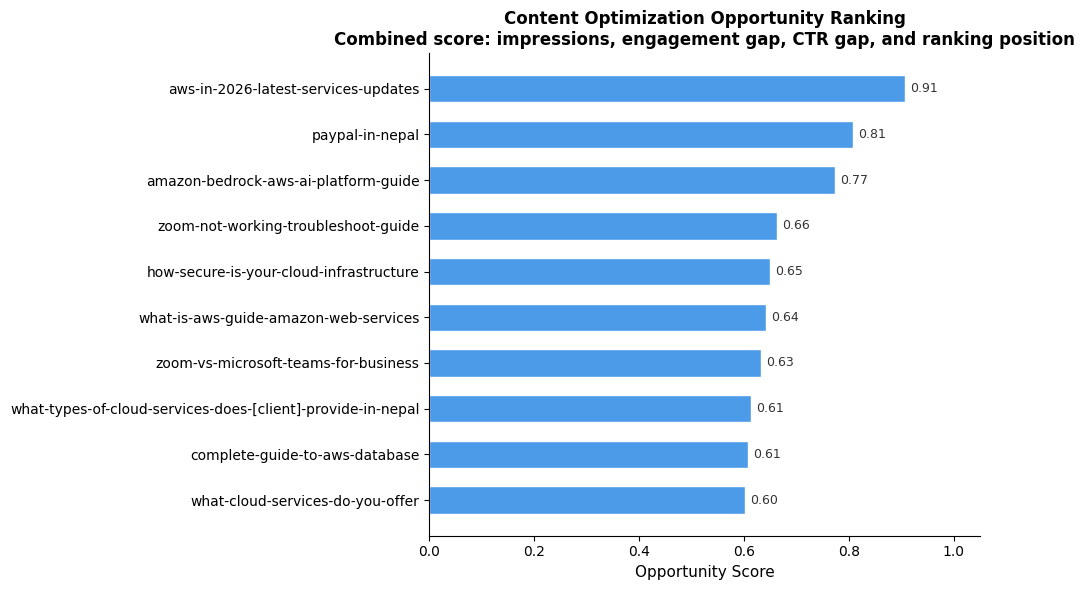

Chart saved to ../output-google/chart/opportunity_score.png


In [22]:
import os
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs('../output-google/chart', exist_ok=True)

# Top opportunity pages
top_opportunities = (
    page_metrics
    .sort_values('opportunity_score', ascending=False)
    .head(10)
    .copy()
)

# Clean labels for readability
top_opportunities['label'] = (
    top_opportunities['Page']
    .str.replace('/blogs/', '', regex=False)
    .str.replace('/faq/', '', regex=False)
    .str.replace('/', '', regex=False)
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(
    top_opportunities['label'][::-1],
    top_opportunities['opportunity_score'][::-1],
    color='#4C9BE8',
    edgecolor='white',
    height=0.6
)

# Score labels
for bar, score in zip(
    bars,
    top_opportunities['opportunity_score'][::-1]
):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.2f}',
        va='center',
        fontsize=9,
        color='#333333'
    )

# Styling
ax.set_xlabel('Opportunity Score', fontsize=11)

ax.set_title(
    'Content Optimization Opportunity Ranking\n'
    'Combined score: impressions, engagement gap, CTR gap, and ranking position',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlim(0, 1.05)

# Clean frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve layout
plt.tight_layout()

# Save chart
plt.savefig(
    '../output-google/chart/opportunity_score.png',
    dpi=150,
    bbox_inches='tight'
)

# Display chart
plt.show()

print("Chart saved to ../output-google/chart/opportunity_score.png")